In [1]:
# [제공 코드] 이 단원에 필요한 라이브러리와 한글 폰트를 준비합니다.
import re
import json
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from kiwipiepy import Kiwi
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

sns.set_theme(style='whitegrid')
import platform

# 한글 폰트 — 실행 중인 OS 에 맞춰 자동 설정
if platform.system() == 'Windows':
    KOREAN_FONT = 'Malgun Gothic'
    FONT_PATH = 'C:/Windows/Fonts/malgun.ttf'
elif platform.system() == 'Darwin':          # macOS
    KOREAN_FONT = 'AppleGothic'
    FONT_PATH = '/System/Library/Fonts/Supplemental/AppleGothic.ttf'
else:                                        # Linux (Colab 등)
    KOREAN_FONT = 'NanumGothic'
    FONT_PATH = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

plt.rcParams['font.family'] = KOREAN_FONT
plt.rcParams['axes.unicode_minus'] = False   # 마이너스(−) 부호 깨짐 방지

kiwi = Kiwi()   # 한국어 형태소 분석기(자바 불필요)

In [2]:
qna_csv = pd.read_csv('../data/processed/inven_question_final.csv')

with open('../data/processed/stopwords_ko.json', encoding='utf-8') as f:
    stopwords_general = set(json.load(f))

# 뉴비/복귀 유저 관련 데이터를 추출하기 위한 수정된 불용어
stopwords_domain = {'정도', '질문', '드리', '키우', '이번', '맞추', '고민', '생각', '스펙', 
'나오', '어떻', '돌리', '모르', '부탁', '가능', '목표', '올리', '구매', '메이플', '바꾸', '상태', '안녕', 
'사용', '바르', '시간'}

stopwords_all = stopwords_general | stopwords_domain

findwords_domain = {
    "뉴비",
    "메린이",
    "메린",
    "복귀",
    "복귀유저",
    "유입",
    "입문",
    "초보",
}

def tokenize(text):
    """정제 → 형태소 → 품사 필터 → 2글자 이상 → 불용어 제거 → 중복 제거(순서 보존)."""
    tokens = [
        t.form for t in kiwi.tokenize(text)
        if t.tag.startswith(('NN', 'VA', 'VV'))          # 명사·형용사·동사만
        and len(t.form) > 1 
        and t.form not in stopwords_all
    ]
    return list(dict.fromkeys(tokens))  # 중복 제거 (순서 유효)

qna_anal = qna_csv.copy()

# 질문/답변 게시판 데이터를 모두 토큰으로 바꾼다.
tokens_list = [tokenize(t) for t in qna_anal['analysis_text']]
qna_anal['tokens'] = tokens_list

display(qna_anal.info())
display(qna_anal.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4157 entries, 0 to 4156
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   category             4157 non-null   object
 1   title                4157 non-null   object
 2   created_at           4157 non-null   object
 3   views                4157 non-null   int64 
 4   likes                4157 non-null   int64 
 5   content              4157 non-null   object
 6   comment_count        4157 non-null   int64 
 7   title_clean          4157 non-null   object
 8   content_clean        4156 non-null   object
 9   analysis_text        4157 non-null   object
 10  has_question_signal  4157 non-null   bool  
 11  is_question          4157 non-null   bool  
 12  tokens               4157 non-null   object
dtypes: bool(2), int64(3), object(8)
memory usage: 365.5+ KB


None

,category,title,created_at,views,likes,content,comment_count,title_clean,content_clean,analysis_text,has_question_signal,is_question,tokens
0,기타,모멘텀패스 살까요 플러스 나오는 거 살까요?,2026-08-19,36,0,챌섭에서 렌 키우고 있습니다.\r\n지금 렙 284인데 모멘텀패스 사고 다음 주 에...,1,모멘텀패스 살까요 플러스 나오는 거 살까요?,챌섭에서 렌 키우고 있습니다. 지금 렙 284인데 모멘텀패스 사고 다음 주 에픽던전...,모멘텀패스 살까요 플러스 나오는 거 살까요? 챌섭에서 렌 키우고 있습니다. 지금 렙...,True,True,"[모멘텀, 패스, 플러스, 챌섭, 사고, 에픽던전, 익몬, 내일, 프리미엄, 하메,..."
1,기타,자석펫 확률업 공지 하고 하나요??,2026-08-19,143,0,자석펫 사야 하는데\r\n혹시 내일 패치하면 들어올까 해서\r\n공지 하고 하나요?...,0,자석펫 확률업 공지 하고 하나요??,자석펫 사야 하는데 혹시 내일 패치하면 들어올까 해서 공지 하고 하나요?? 공지 안...,자석펫 확률업 공지 하고 하나요?? 자석펫 사야 하는데 혹시 내일 패치하면 들어올까...,True,True,"[자석펫, 확률업, 공지, 자석, 내일, 패치, 들어오]"
2,아이템,울티마 상점떔에 3배 썩어나는데 4배로 교환할수있나요??,2026-08-19,157,0,받기전 3배 이벤창에서밖에 교환못함요...?,2,울티마 상점떔에 3배 썩어나는데 4배로 교환할수있나요??,받기전 3배 이벤창에서밖에 교환못함요..?,울티마 상점떔에 3배 썩어나는데 4배로 교환할수있나요?? 받기전 3배 이벤창에서밖에...,True,True,"[울티마, 상점, 교환]"


In [3]:
from collections import Counter, defaultdict

pos_counter_by_cat = defaultdict(Counter)

# 1. 카테고리별로 조건에 맞는 tokens 집계
for category, views, tokens in zip(qna_anal['category'], qna_anal['views'], qna_anal['tokens']):
    if views >= 1:
        # 해당 카테고리의 Counter에만 단어 개수 누적
        pos_counter_by_cat[category].update(tokens)

# 2. 카테고리별로 상위 5개 단어 추출 및 출력
for cat, counter in pos_counter_by_cat.items():
    # counter.most_common(5)로 상위 5개 (단어, 개수) 추출
    top5_words = [f'{w} ({n})' for w, n in counter.most_common(5)]
    
    compare = pd.DataFrame({
        f'"{cat}" 카테고리에서 가장 많이 언급된 단어 top5': top5_words
    }, index=range(1, 6))
    
    display(compare)

,"""기타"" 카테고리에서 가장 많이 언급된 단어 top5"
1,챌섭 (350)
2,보스 (139)
3,뉴비 (135)
4,패스 (128)
5,사냥 (117)


,"""아이템"" 카테고리에서 가장 많이 언급된 단어 top5"
1,챌섭 (505)
2,무기 (386)
3,보조 (352)
4,미트라 (260)
5,뉴비 (255)


,"""퀘스트"" 카테고리에서 가장 많이 언급된 단어 top5"
1,해방 (31)
2,보스 (21)
3,퀘스트 (18)
4,챌섭 (17)
5,뉴비 (14)


,"""직업"" 카테고리에서 가장 많이 언급된 단어 top5"
1,직업 (122)
2,챌섭 (113)
3,추천 (90)
4,레테 (77)
5,뉴비 (66)


,"""시세"" 카테고리에서 가장 많이 언급된 단어 top5"
1,시세 (53)
2,가격 (37)
3,챌섭 (31)
4,팔리 (17)
5,뉴비 (16)


,"""몬스터"" 카테고리에서 가장 많이 언급된 단어 top5"
1,배율 (40)
2,패턴 (22)
3,보스 (22)
4,극딜 (20)
5,하드 (19)


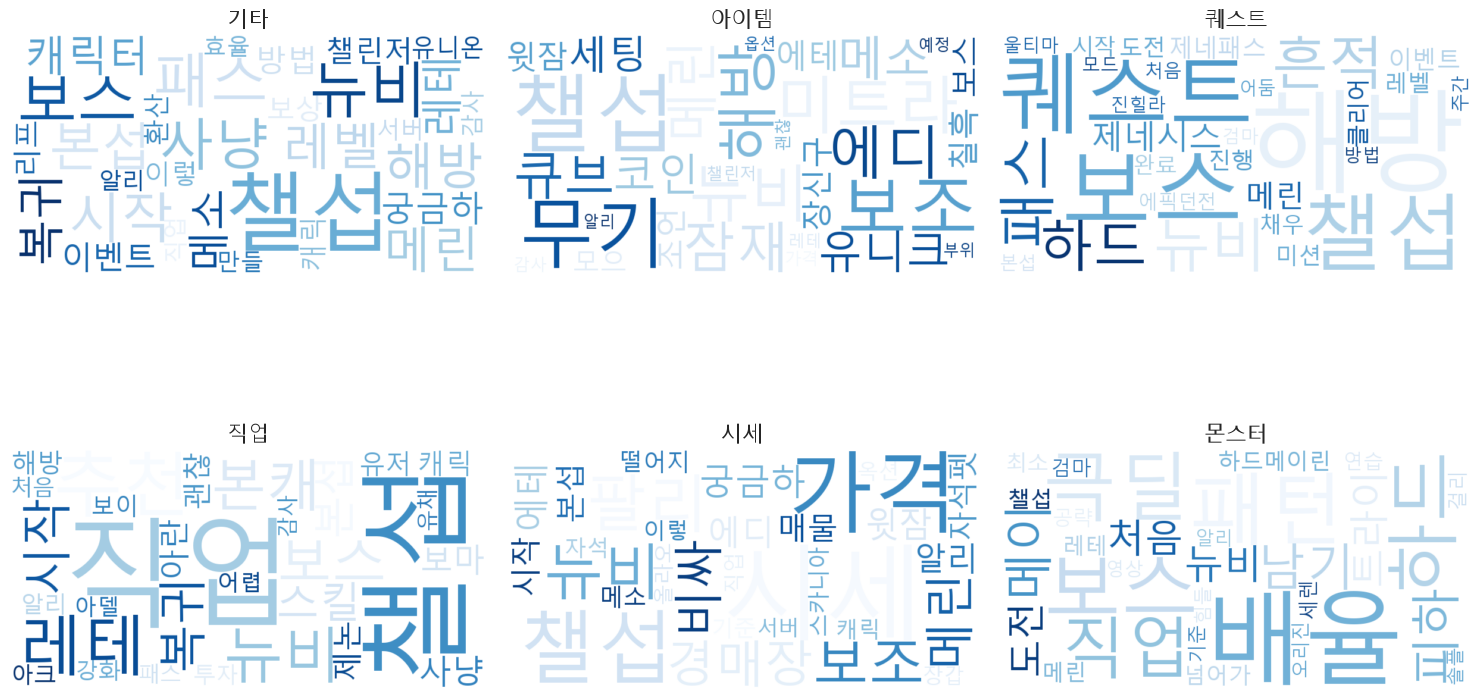

큰 글자일수록 자주 나온 단어 — 빈도를 그대로 크기로 옮긴 그림이다


In [ ]:
from math import ceil

categories = list(pos_counter_by_cat.keys())
n_categories = len(categories)
n_cols = 3
n_rows = ceil(n_categories / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 5 * n_rows)
)

axes = np.array(axes).reshape(-1)

# n_categories = len(categories)

# fig, axes = plt.subplots(1, len(pos_counter_by_cat), figsize=(14, 5))

if len(pos_counter_by_cat) == 1:
    axes = [axes]

for ax, (category, counter) in zip(axes, pos_counter_by_cat.items()):
    wc = WordCloud(
        font_path=FONT_PATH,
        width=800, height=400,
        background_color='white',
        colormap='Blues',
        max_words=30, min_font_size=10, collocations=False
    ).generate_from_frequencies(counter)

    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(category, fontsize=15)
    ax.axis('off')


for ax in axes[n_categories:]:
    ax.axis('off')

fig.tight_layout()
plt.show()

In [ ]:
from pathlib import Path

OUTPUT_DIR = Path("../인벤데이터 시각화/outputs")
FIGURE_DIR = Path("../인벤데이터 시각화/figures")

FIGURE_PATH = FIGURE_DIR / "category_word_cloud.png"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

fig.savefig(
    FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

print(f"그림 저장 완료: {FIGURE_PATH}")

# 대시보드(src/streamlit/pages/대시보드.py)가 읽어갈 단어 빈도 CSV
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CSV_PATH = OUTPUT_DIR / "category_word_counts.csv"

rows = [
    {"category": category, "word": word, "count": count, "rank": rank}
    for category, counter in pos_counter_by_cat.items()
    for rank, (word, count) in enumerate(counter.most_common(30), start=1)
]
pd.DataFrame(rows).to_csv(CSV_PATH, index=False, encoding="utf-8-sig")

print(f"CSV 저장 완료: {CSV_PATH} ({len(rows)}행)")
